In [2]:
import pandas as pd
import editdistance
import matplotlib.pyplot as plt
from run import load_data
from char_tokeniser import CharTokeniser

train, val, test = load_data()
tokeniser = CharTokeniser(train)

# Mean word/phoneme length across entire dataset

In [6]:
all_data = pd.concat([train, val, test])
word_lengths = all_data['word'].apply(len)
ipa_lengths = all_data['ipa'].apply(lambda x: len(tokeniser.ipa_to_units(x)))

print(f"Mean word length: {word_lengths.mean():.2f} (SD {word_lengths.std():.2f})")
print(f"Mean ipa length: {ipa_lengths.mean():.2f} (SD {ipa_lengths.std():.2f})")

Mean word length: 8.82 (SD 2.64)
Mean ipa length: 9.65 (SD 2.65)


# Plots

In [13]:
train_log = pd.read_csv('train_log.csv')
best_epoch = train_log['val_per'].idxmin() + 1
train_log = train_log[:best_epoch]
train_log['val_wer'] = 1 - train_log['val_wacc']
train_log

,epoch,train_loss,val_loss,val_per,val_wacc,val_wer
0,0,3.850845,2.969983,0.877096,0.000000,1.000000
1,1,3.078576,2.626270,0.832249,0.000000,1.000000
2,2,2.796608,2.419609,0.752359,0.000000,1.000000
3,3,2.602665,2.276208,0.710973,0.000000,1.000000
4,4,2.446740,2.119356,0.685468,0.000000,1.000000
...,...,...,...,...,...,...
308,308,0.023108,0.112235,0.034524,0.833333,0.166667
309,309,0.021185,0.115424,0.033091,0.840000,0.160000
310,310,0.022225,0.111008,0.033604,0.840000,0.160000
311,311,0.023740,0.113205,0.034010,0.836667,0.163333


In [14]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "text.usetex": False, 
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 300
})

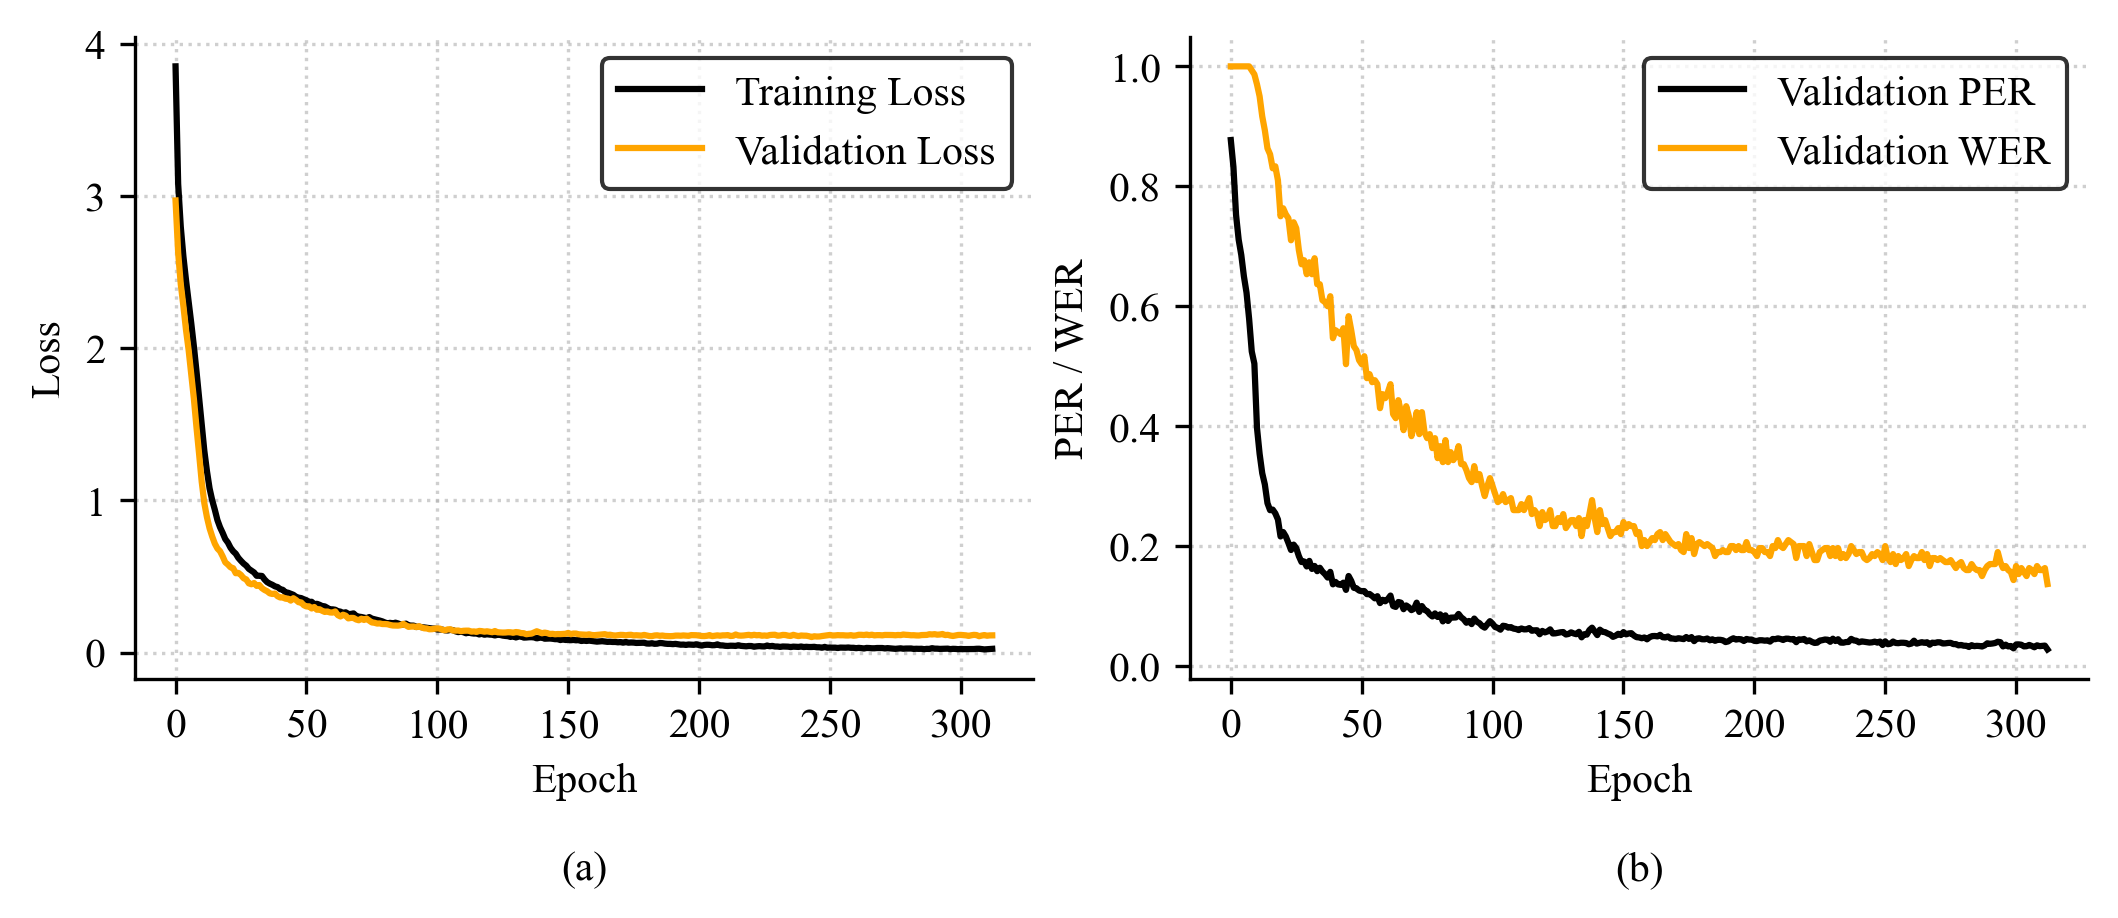

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3))

ax1.plot(train_log['epoch'], train_log['train_loss'], 
        label='Training Loss', 
        color='black', 
        linestyle='-', 
        linewidth=1.5,
        )

ax1.plot(train_log['epoch'], train_log['val_loss'], 
        label='Validation Loss', 
        color='orange', 
        linestyle='-', 
        linewidth=1.5,
        )

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.legend(frameon=True, loc='upper right', edgecolor='black')
ax1.set_xlabel('Epoch\n\n(a)')

ax2.plot(train_log['epoch'], train_log['val_per'], 
        label='Validation PER', 
        color='black', 
        linestyle='-', 
        linewidth=1.5,
        )

ax2.plot(train_log['epoch'], train_log['val_wer'], 
        label='Validation WER', 
        color='orange', 
        linestyle='-', 
        linewidth=1.5,
        )

ax2.set_xlabel('Epoch')
ax2.set_ylabel('PER / WER')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.legend(frameon=True, loc='upper right', edgecolor='black')
ax2.set_xlabel('Epoch\n\n(b)')

plt.tight_layout(pad=0.5)
plt.savefig('essay/figs/loss.png', dpi=300, bbox_inches='tight')
plt.show()

# Results analysis

In [3]:
def evaluate_results(results: pd.DataFrame, tokeniser):
    results = results.copy()
    results['word_length'] = results['word'].apply(len) # Length of input word
    results['ipa_length'] = results['ipa'].apply(lambda x: len(tokeniser.ipa_to_units(x))) # Number of phonemes

    results['edit_distance'] = results.apply(
        lambda row: editdistance.eval(
            tokeniser.ipa_to_units(row['prediction']),
            tokeniser.ipa_to_units(row['ipa'])
            ), axis=1)

    results['per'] = results['edit_distance'] / results['ipa_length']
    results['exact_match'] = results['ipa'] == results['prediction']

    print(f"PER: {results['per'].mean() * 100:.2f}%")
    print(f"WER: {(1 - results['exact_match'].mean()) * 100:.2f}%")

    return results

In [9]:
train_results = pd.read_csv('results/train_results.csv')
train_results = evaluate_results(train_results, tokeniser)

PER: 0.01%
WER: 0.05%


In [4]:
val_results = pd.read_csv('results/val_results.csv')
val_results = evaluate_results(val_results, tokeniser)

PER: 2.93%
WER: 14.67%


In [4]:
test_results = pd.read_csv('results/test_results.csv')
test_results = evaluate_results(test_results, tokeniser)

PER: 3.73%
WER: 16.00%


## Failures list

In [5]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(test_results[test_results['exact_match'] == False])

,word,ipa,prediction,word_length,ipa_length,edit_distance,per,exact_match
0,sangra,ˈs a n ɡ ɾ a,s a n ˈɡ ɾ a,6,7,2,0.285714,False
7,horroroso,o r o ˈɾ o s o,o ˈr o ɾ o s o s,9,8,3,0.375000,False
13,supramediterráneo,s u p ɾ a m e d i t e ˈr a n e o,s u p ɾ a m e d i ˈt e ɾ a,17,17,6,0.352941,False
16,alondra,a ˈl o n d ɾ a,a l o ˈn d ɾ a,7,8,2,0.250000,False
21,guío,ˈɡ i o,ˈɡ i i o,4,4,1,0.250000,False
35,ventriloquia,b e n t ɾ i ˈl o k j a,b e n t ɾ i l o ˈk w j a,12,12,3,0.250000,False
36,atenuantes,a t e ˈn w a n t e s,a t e n u ˈa n t e s,10,11,3,0.272727,False
42,pertrechados,p e ɾ t ɾ e ˈt͡ʃ a d o s,p e ɾ t ɾ e t͡ʃ a ˈd o s,12,12,2,0.166667,False
47,amigdalectomía,a m i ɡ d a l e ɡ t o ˈm i a,a m i ɡ d a l e ɡ ˈt o m a,14,15,3,0.200000,False
49,siútico,ˈs j u t i k o,s i ˈu t i k o,7,8,3,0.375000,False


## Stats of test failures

In [9]:
test_results[test_results['exact_match'] == False]['per'].mean() * 100

np.float64(23.286402754523884)

In [24]:
test_results[test_results['exact_match'] == False]['edit_distance'].mean()

np.float64(2.2291666666666665)

In [16]:
test_results[test_results['exact_match'] == True]['ipa_length'].max()

np.int64(17)

# Grapheme to most predicted phoneme

`SequenceMatcher` from difflib has the method `.get_opcodes()` which returns a list of 5-tuples explaining how to turn the gold sequence into the predicted sequence. 

'replace' `a[i1:i2]` should be replaced by `b[j1:j2]`.

'delete'  a[i1:i2] should be deleted. Note that `j1 == j2` in this case.

'insert'  `b[j1:j2]` should be inserted at `a[i1:i1]`. Note that i1 == i2 in this case.

'equal'   `a[i1:i2] == b[j1:j2]` (the sub-sequences are equal).

In [25]:
from difflib import SequenceMatcher
from collections import defaultdict

mappings = defaultdict(list)

for gold, pred in zip(test_results['ipa'], test_results['prediction']):
    gold = tokeniser.ipa_to_units(gold)
    pred = tokeniser.ipa_to_units(pred)
    
    matcher = SequenceMatcher(None, pred, gold)
    for tag, i1, i2, j1, j2 in matcher.get_opcodes():
        if tag == 'equal' or tag == 'replace':
            for i, j in zip(pred[i1:i2], gold[j1:j2]):
                mappings[i].append(j)
        elif tag == 'delete':
            for i in pred[i1:i2]:
                mappings[i].append('<del>')

sorted_mappings = dict(sorted(mappings.items(), key=lambda x: len(x[1]), reverse=True))
mappings_set = {k: set(v) for k, v in sorted_mappings.items()}

In [26]:
mappings_set

{'a': {'<del>', 'a'},
 'ˈ': {'<del>', 'ˈ'},
 'o': {'<del>', 'o'},
 'e': {'<del>', 'e'},
 'i': {'<del>', 'e', 'i', 'j'},
 'ɾ': {'<del>', 'ɾ', 'ˈ'},
 's': {'<del>', 's'},
 'd': {'d'},
 't': {'t'},
 'n': {'n'},
 'k': {'k'},
 'l': {'<del>', 'l', 'ˈ'},
 'm': {'m'},
 'b': {'b'},
 'p': {'<del>', 'p'},
 'u': {'u', 'w'},
 'ɡ': {'ɡ'},
 'f': {'f'},
 'j': {'<del>', 'j'},
 'x': {'<del>', 'x'},
 'r': {'<del>', 'r'},
 'ʝ': {'k', 'l', 'ʝ'},
 't͡ʃ': {'t͡ʃ'},
 'w': {'<del>', 'w'},
 'ɲ': {'o', 'ɲ'}}

## Repeated phonemes in training data

In [11]:
for ipa in test_results['prediction']:
    ipa = tokeniser.ipa_to_units(ipa)

    for i in range(len(ipa)):
        if i < len(ipa) -1:
            if ipa[i] == ipa[i+1]:
                print("".join(ipa))
    


ˈɡiio
koˈreaxxe
kebɾaˈt͡ʃoo
kommutatiˈbida
ˈaɲɲ


In [14]:
count = 0
for word in train_results['word']:
    for char in word:
        if char in {'á', 'é', 'í', 'ó', 'ú'}:
            count += 1
print(count)

387
